In [2]:
# =============================================================================
# SVR — Wind Speed Forecasting
# =============================================================================
!pip install optuna
# =============================================================================
# INSTALLING PACKAGES
# =============================================================================
# !pip install statsmodels optuna tabulate gdown

# =============================================================================
# IMPORTS
# =============================================================================

# Standard libraries
import os
import sys
import random
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap

# Scikit-learn: preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn import model_selection, metrics, preprocessing

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)

# Scikit-learn: models & metrics
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pointbiserialr, chi2_contingency, spearmanr, entropy, uniform
from statsmodels.graphics.gofplots import qqplot

# Tabulate
from tabulate import tabulate

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress Optuna trial logs

# Google Drive download
import gdown

# Global random seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.2 MB/s eta 0:00:00


In [3]:

# =============================================================================
# LOADING THE DATA SET
# =============================================================================
# Dataset source:
# https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
# https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing

file_id = "1qhCB1Dod6jeEsuKy5sNk4MNHSjtENSrx"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the data
df = pd.read_csv(download_url)

# Backup original DataFrame
df_backup = df.copy()


# =============================================================================
# DATA PREPROCESSING
# =============================================================================

# Create datetime directly from differently named columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})

# Set Date as the index
df = df.set_index('Date')

# Drop unnecessary columns
df = df.drop(columns=["YEAR", "MO", "DY"])

# Display the DataFrame (optional in scripts)
print(df.head())
print("\nColumns:", df.columns.tolist())




            WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79       1.65  

In [4]:
# =============================================================================
# TRAIN / TEST SPLIT  (80% train — 20% test, temporal order preserved)
# =============================================================================
## Data Sets

# Define features and target
X = df.drop(columns=['WS10M'])   # Features (all columns except target)
y = df['WS10M']                  # Target variable (wind speed)

numerical_cols = df.columns

# Define the split index — 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

# Training set
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing set
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("X_train:\n", X_train.head())
print("y_train:\n", y_train.head())
print("X_test:\n",  X_test.head())
print("y_test:\n",  y_test.head())

print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)




X_train:
             WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79   

In [5]:

# =============================================================================
# SCALING
# FIX: Scaler is fit once on X_train only and reused across all sections.
#      Fitting the scaler separately in each section is redundant and risks
#      inconsistency if X_train ever changes between sections.
# =============================================================================
# With Scaling

# Initialize scaler — fit on training data only, never on test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit and transform train
X_test_scaled  = scaler.transform(X_test)        # Transform test using train statistics


# =============================================================================
# EVALUATION FUNCTION  (defined once, reused across all sections)
# =============================================================================
# Evaluation Function
def evaluate_metrics(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2




--- SVR Original Model Evaluation ---
Train (SVR) MSE:  0.3786
Train (SVR) RMSE: 0.6153
Train (SVR) MAE:  0.4556
Train (SVR) MAPE: 12.45%
Train (SVR) R²:   0.8497
Test (SVR) MSE:  0.5571
Test (SVR) RMSE: 0.7464
Test (SVR) MAE:  0.5680
Test (SVR) MAPE: 15.25%
Test (SVR) R²:   0.7690


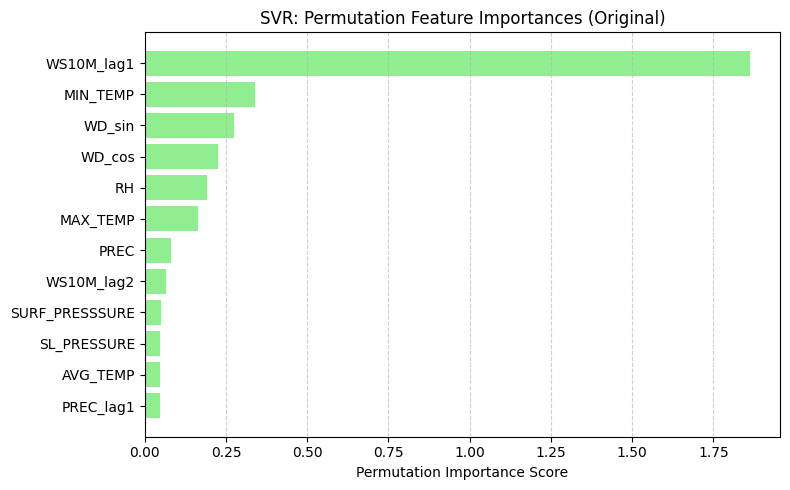

In [6]:
# =============================================================================
# SECTION 1 — ORIGINAL SVR MODEL  (No Hyperparameter Optimisation)
# =============================================================================
## Original

# Initialize the SVR model
svr_model = SVR(
    kernel='rbf',    # You can try 'linear', 'poly', 'sigmoid'
    C=1.0,           # Regularization parameter
    epsilon=0.1      # Margin of tolerance
)

# Fit the model on scaled training data
svr_model.fit(X_train_scaled, y_train)

# Predict on train and test
y_train_pred_svr = svr_model.predict(X_train_scaled)
y_test_pred_svr  = svr_model.predict(X_test_scaled)

# Evaluate (uses evaluate_metrics defined above)
print("\n--- SVR Original Model Evaluation ---")
svr_train_mse,  svr_train_rmse,  svr_train_mae,  svr_train_mape,  svr_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_svr, label="Train (SVR)")
svr_test_mse,   svr_test_rmse,   svr_test_mae,   svr_test_mape,   svr_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_svr,  label="Test (SVR)")

# === Feature Importance using Permutation ===
result_svr_orig = permutation_importance(
    svr_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)

importance_df_svr = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': result_svr_orig.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df_svr['Feature'], importance_df_svr['Importance'], color='lightgreen')
plt.xlabel('Permutation Importance Score')
plt.title('SVR: Permutation Feature Importances (Original)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Parameters (Grid Search):
{'C': 10, 'epsilon': 0.2, 'gamma': 0.01, 'kernel': 'rbf'}

--- Grid Search SVR Evaluation ---
Train (SVR Grid Search) MSE:  0.4278
Train (SVR Grid Search) RMSE: 0.6541
Train (SVR Grid Search) MAE:  0.5027
Train (SVR Grid Search) MAPE: 14.10%
Train (SVR Grid Search) R²:   0.8302
Test (SVR Grid Search) MSE:  0.5500
Test (SVR Grid Search) RMSE: 0.7416
Test (SVR Grid Search) MAE:  0.5693
Test (SVR Grid Search) MAPE: 15.51%
Test (SVR Grid Search) R²:   0.7719


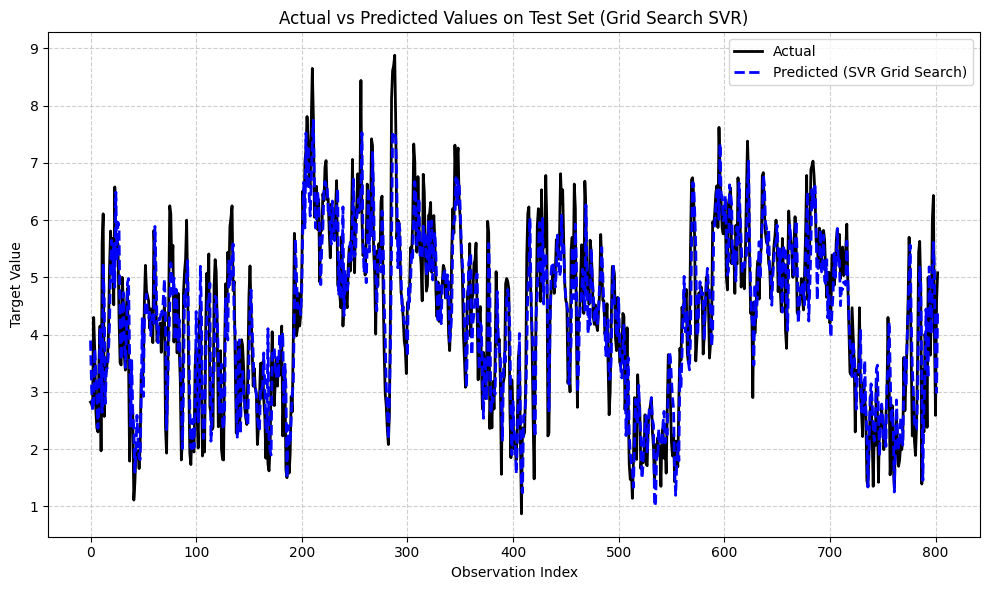

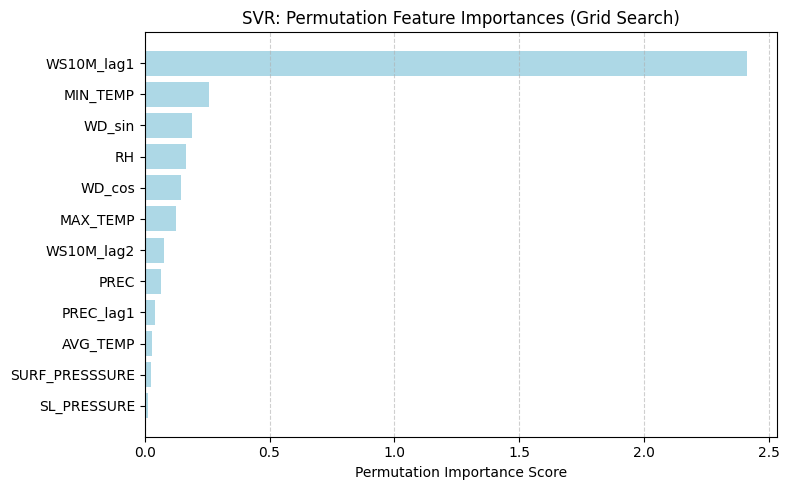

In [7]:

# =============================================================================
# SECTION 2 — GRID SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Grid Search

# Extended hyperparameter grid for SVR
param_grid = {
    'C':       [0.1, 1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.3],
    'gamma':   ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel':  ['rbf']    # You can include 'linear' or 'poly' as well
}

# Initialize SVR model
svr_grid = SVR()

# Time series-aware cross-validation — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# Grid Search — fitted on X_train_scaled only (no test set exposure)
grid_search = GridSearchCV(
    estimator=svr_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    refit=True    # Refit best model on full X_train_scaled automatically
)

# Fit Grid Search on scaled training data only
grid_search.fit(X_train_scaled, y_train)

# Best SVR model
best_svr_grid = grid_search.best_estimator_
print("\nBest Parameters (Grid Search):")
print(grid_search.best_params_)

# --- Optimal performance: predict on full X_train_scaled and X_test_scaled ---
y_train_pred_svr_grid = best_svr_grid.predict(X_train_scaled)
y_test_pred_svr_grid  = best_svr_grid.predict(X_test_scaled)

# Evaluation
print("\n--- Grid Search SVR Evaluation ---")
grid_train_mse,  grid_train_rmse,  grid_train_mae,  grid_train_mape,  grid_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_svr_grid, label="Train (SVR Grid Search)")
grid_test_mse,   grid_test_rmse,   grid_test_mae,   grid_test_mape,   grid_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_svr_grid,  label="Test (SVR Grid Search)")

# Plot actual vs predicted values on the test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,             label='Actual',                   color='black', linewidth=2)
plt.plot(y_test_pred_svr_grid,      label='Predicted (SVR Grid Search)', color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Values on Test Set (Grid Search SVR)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Permutation Feature Importance
perm_result_grid = permutation_importance(
    best_svr_grid,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)

importance_df_grid = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_result_grid.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot permutation importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df_grid['Feature'], importance_df_grid['Importance'], color='lightblue')
plt.xlabel('Permutation Importance Score')
plt.title('SVR: Permutation Feature Importances (Grid Search)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters (Randomized Search):
{'C': np.float64(11.686905952512971), 'epsilon': np.float64(0.2689310277626781), 'gamma': 0.01, 'kernel': 'rbf'}

--- Randomized Search SVR Evaluation ---
Train (SVR Randomized Search) MSE:  0.4238
Train (SVR Randomized Search) RMSE: 0.6510
Train (SVR Randomized Search) MAE:  0.5014
Train (SVR Randomized Search) MAPE: 14.07%
Train (SVR Randomized Search) R²:   0.8318
Test (SVR Randomized Search) MSE:  0.5444
Test (SVR Randomized Search) RMSE: 0.7378
Test (SVR Randomized Search) MAE:  0.5646
Test (SVR Randomized Search) MAPE: 15.40%
Test (SVR Randomized Search) R²:   0.7742


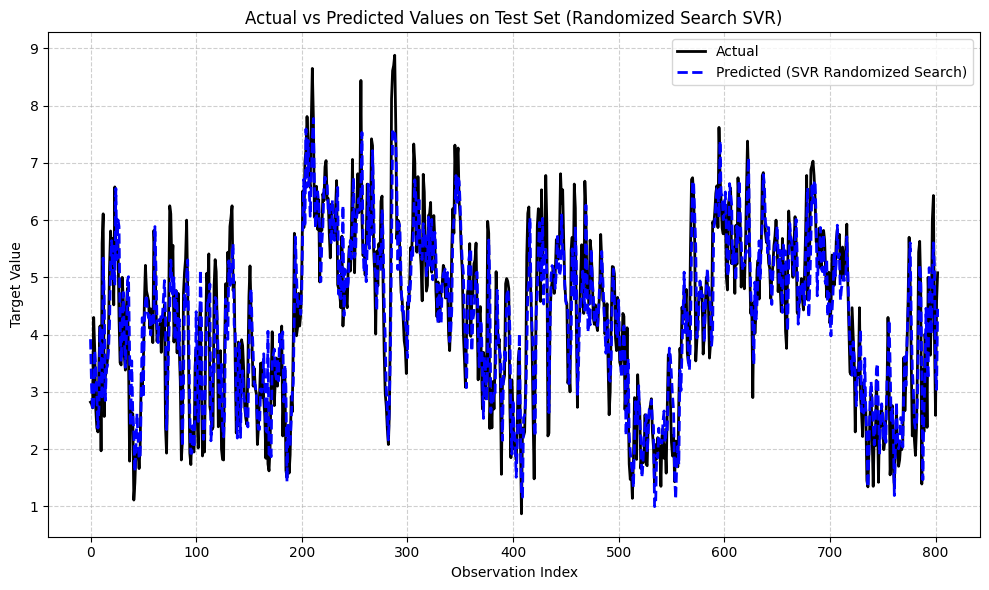

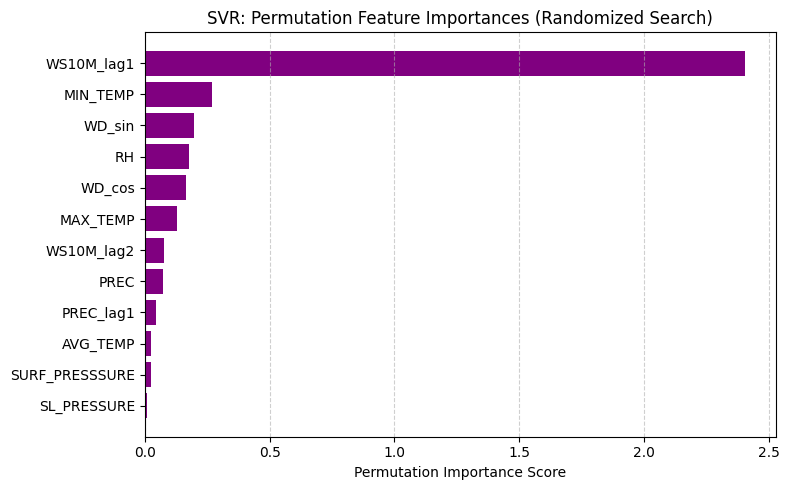

In [8]:
# =============================================================================
# SECTION 3 — RANDOMIZED SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Random Search

# Hyperparameter distribution for SVR
param_dist = {
    'C':       uniform(loc=0.1, scale=100),          # Range: 0.1 to 100.1
    'epsilon': uniform(loc=0.01, scale=0.3),         # Range: 0.01 to 0.31
    'gamma':   ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel':  ['rbf']                               # 'linear', 'poly' can be added
}

# Initialize model
svr_random = SVR()

# Time Series Cross-Validation — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# Randomized Search — fitted on X_train_scaled only (no test set exposure)
random_search = RandomizedSearchCV(
    estimator=svr_random,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True    # Refit best model on full X_train_scaled automatically
)

# Fit search on scaled training data only
random_search.fit(X_train_scaled, y_train)

# Best model
best_svr_random = random_search.best_estimator_
print("\nBest Parameters (Randomized Search):")
print(random_search.best_params_)

# --- Optimal performance: predict on full X_train_scaled and X_test_scaled ---
y_train_pred_svr_random = best_svr_random.predict(X_train_scaled)
y_test_pred_svr_random  = best_svr_random.predict(X_test_scaled)

# Evaluation
print("\n--- Randomized Search SVR Evaluation ---")
random_train_mse,  random_train_rmse,  random_train_mae,  random_train_mape,  random_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_svr_random, label="Train (SVR Randomized Search)")
random_test_mse,   random_test_rmse,   random_test_mae,   random_test_mape,   random_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_svr_random,  label="Test (SVR Randomized Search)")

# Plot actual vs predicted values on the test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,              label='Actual',                        color='black',  linewidth=2)
plt.plot(y_test_pred_svr_random,     label='Predicted (SVR Randomized Search)', color='blue', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Values on Test Set (Randomized Search SVR)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Permutation Feature Importance (since SVR has no feature_importances_)
perm_result_random = permutation_importance(
    best_svr_random,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)

importance_df_random = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_result_random.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot permutation importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df_random['Feature'], importance_df_random['Importance'], color='purple')
plt.xlabel('Permutation Importance Score')
plt.title('SVR: Permutation Feature Importances (Randomized Search)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Best Trial:
FrozenTrial(number=25, state=<TrialState.COMPLETE: 1>, values=[0.5182680804021856], datetime_start=datetime.datetime(2026, 3, 10, 4, 42, 27, 589463), datetime_complete=datetime.datetime(2026, 3, 10, 4, 42, 29, 626907), params={'C': 18.822220249563276, 'epsilon': 0.20191336223901618, 'gamma': 0.01, 'kernel': 'rbf'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'C': FloatDistribution(high=100.0, log=True, low=0.1, step=None), 'epsilon': FloatDistribution(high=0.3, log=False, low=0.01, step=None), 'gamma': CategoricalDistribution(choices=('scale', 'auto', 0.001, 0.01, 0.1)), 'kernel': CategoricalDistribution(choices=('rbf',))}, trial_id=25, value=None)

Best Parameters (Optuna):
{'C': 18.822220249563276, 'epsilon': 0.20191336223901618, 'gamma': 0.01, 'kernel': 'rbf'}

--- Optimized SVR Evaluation (Optuna) ---
Train (SVR Optuna) MSE:  0.4140
Train (SVR Optuna) RMSE: 0.6434
Train (SVR Optuna) MAE:  0.4945
Train (SVR Optuna) MAPE: 13.84%
Train (SVR Optu

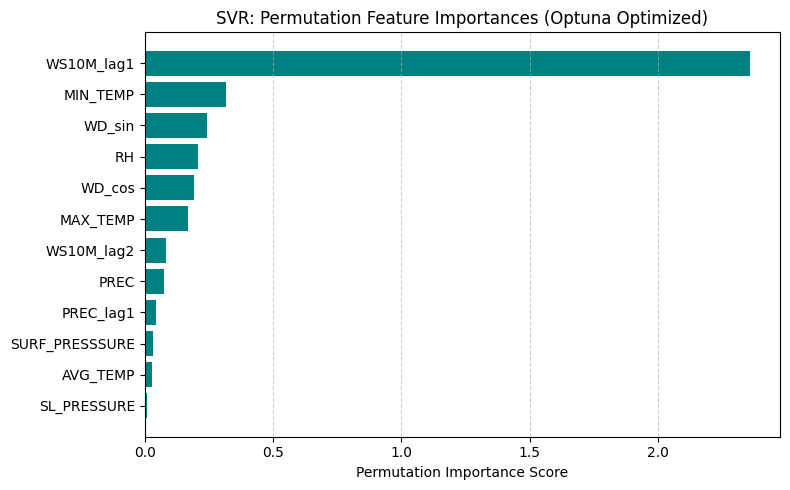

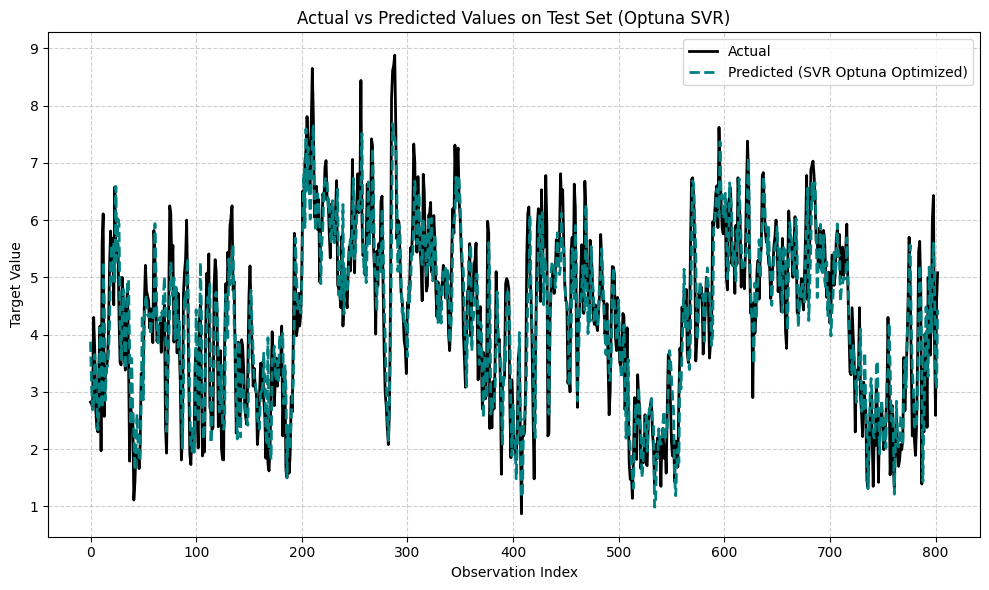

In [9]:
# =============================================================================
# SECTION 4 — OPTUNA  Hyperparameter Tuning
# FIX: Original code split X_train_sub (scaled array) for indices but then
#      fitted the model on X_train.iloc[...] (unscaled). Hyperparameters were
#      therefore tuned on raw features while the final model used scaled features —
#      a direct inconsistency corrupting Optuna's search.
#      Fixed: CV folds inside the objective now consistently use X_train_scaled.
# =============================================================================
## Optuna

# Optuna objective function for SVR
def svr_objective(trial):
    params = {
        # FIX: suggest_loguniform is deprecated — replaced with suggest_float(..., log=True)
        'C':       trial.suggest_float('C', 0.1, 100.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 0.3),
        'gamma':   trial.suggest_categorical('gamma', ['scale', 'auto', 0.001, 0.01, 0.1]),
        'kernel':  trial.suggest_categorical('kernel', ['rbf'])    # You can add 'linear', 'poly'
    }

    # Use TimeSeriesSplit CV on X_train_scaled only — avoids any exposure to held-out X_test
    # FIX: previously the fold fit used unscaled X_train.iloc[...] while indices came
    #      from the scaled X_train_scaled array — now both are consistently scaled
    tscv_optuna = TimeSeriesSplit(n_splits=5)
    mse_scores  = []

    for fold_train_idx, fold_val_idx in tscv_optuna.split(X_train_scaled):
        X_fold_tr  = X_train_scaled[fold_train_idx]
        X_fold_val = X_train_scaled[fold_val_idx]
        y_fold_tr  = y_train.iloc[fold_train_idx]
        y_fold_val = y_train.iloc[fold_val_idx]

        model = SVR(**params)
        model.fit(X_fold_tr, y_fold_tr)
        preds = model.predict(X_fold_val)
        mse_scores.append(mean_squared_error(y_fold_val, preds))

    # Return the mean CV MSE across all folds — no test set exposure
    return np.mean(mse_scores)

# Run Optuna optimisation
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(svr_objective, n_trials=30, timeout=300)

# Results
print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters (Optuna):")
print(study.best_params)

# --- Optimal performance: refit on full X_train_scaled, evaluate on X_train_scaled and X_test_scaled ---
best_svr_optuna = SVR(**study.best_params)
best_svr_optuna.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_svr_optuna = best_svr_optuna.predict(X_train_scaled)
y_test_pred_svr_optuna  = best_svr_optuna.predict(X_test_scaled)

# Evaluation
print("\n--- Optimized SVR Evaluation (Optuna) ---")
optuna_train_mse,  optuna_train_rmse,  optuna_train_mae,  optuna_train_mape,  optuna_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_svr_optuna, label="Train (SVR Optuna)")
optuna_test_mse,   optuna_test_rmse,   optuna_test_mae,   optuna_test_mape,   optuna_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_svr_optuna,  label="Test (SVR Optuna)")

# Optional: Permutation Feature Importance
perm_result_optuna = permutation_importance(
    best_svr_optuna,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)

importance_df_optuna = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_result_optuna.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot permutation importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df_optuna['Feature'], importance_df_optuna['Importance'], color='teal')
plt.xlabel('Permutation Importance Score')
plt.title('SVR: Permutation Feature Importances (Optuna Optimized)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot actual vs predicted values on the test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,              label='Actual',                          color='black', linewidth=2)
plt.plot(y_test_pred_svr_optuna,     label='Predicted (SVR Optuna Optimized)', color='teal', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Values on Test Set (Optuna SVR)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [10]:

# =============================================================================
# FINAL COMPARISON TABLE
# Optimal train/test performance for each method
# (best model refitted on full X_train_scaled, evaluated on held-out X_test_scaled)
# =============================================================================

results = {
    "Method": ["Original Model", "Grid Search", "Randomized Search", "Optuna"],

    "Train MSE":      [svr_train_mse,   grid_train_mse,   random_train_mse,   optuna_train_mse],
    "Test MSE":       [svr_test_mse,    grid_test_mse,    random_test_mse,    optuna_test_mse],

    "Train MAE":      [svr_train_mae,   grid_train_mae,   random_train_mae,   optuna_train_mae],
    "Test MAE":       [svr_test_mae,    grid_test_mae,    random_test_mae,    optuna_test_mae],

    "Train RMSE":     [svr_train_rmse,  grid_train_rmse,  random_train_rmse,  optuna_train_rmse],
    "Test RMSE":      [svr_test_rmse,   grid_test_rmse,   random_test_rmse,   optuna_test_rmse],

    "Train MAPE (%)": [svr_train_mape,  grid_train_mape,  random_train_mape,  optuna_train_mape],
    "Test MAPE (%)":  [svr_test_mape,   grid_test_mape,   random_test_mape,   optuna_test_mape],

    "Train R²":       [svr_train_r2,    grid_train_r2,    random_train_r2,    optuna_train_r2],
    "Test R²":        [svr_test_r2,     grid_test_r2,     random_test_r2,     optuna_test_r2],
}

# Convert dictionary to Pandas DataFrame
df_results = pd.DataFrame(results)

# Print the title
print("\n" + "=" * 60)
print("   Variable Set 1 — SVR Modelling")
print("   (Optimal Train/Test Performance per Method)")
print("=" * 60 + "\n")

# Display the table
print(df_results.to_string(index=False))

# Save the DataFrame to a CSV file
df_results.to_csv("variableSet_1_svr_results.csv", index=False)
print("\nResults saved to 'variableSet_1_svr_results.csv'")



   Variable Set 1 — SVR Modelling
   (Optimal Train/Test Performance per Method)

           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.378558  0.557121   0.455629  0.568013    0.615271   0.746405       12.450176      15.248975  0.849737 0.768968
      Grid Search   0.427790  0.549987   0.502684  0.569317    0.654057   0.741611       14.095618      15.512561  0.830195 0.771926
Randomized Search   0.423840  0.544405   0.501391  0.564562    0.651030   0.737838       14.074024      15.399762  0.831763 0.774241
           Optuna   0.413973  0.540667   0.494474  0.562400    0.643407   0.735301       13.835408      15.287381  0.835679 0.775791

Results saved to 'variableSet_1_svr_results.csv'
